In [1]:
import torch
from torch import nn

In [2]:
import os
!pip install opendatasets
import opendatasets as od

In [3]:
od.download('https://www.kaggle.com/datasets/ahedjneed/fancy-watche-images')

Skipping, found downloaded files in "./fancy-watche-images" (use force=True to force download)


In [4]:
import requests
import zipfile
from pathlib import Path
os.listdir('fancy-watche-images/content/images')

['watches.csv',
 'Breitling',
 'Tissot',
 'Patek Philippe',
 'Rolex',
 'Omega',
 'Breguet',
 'Rado',
 'Audemars Piguet',
 'Maurice Lacroix',
 'Vacheron Constantin']

In [5]:

import shutil
from sklearn.model_selection import train_test_split

In [6]:
base_dir = 'fancy-watche-images/content/images'
train_dir = 'fancy-watche-images/content/train'
test_dir = 'fancy-watche-images/content/test'


In [7]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


In [8]:
watch_brands = os.listdir(base_dir)


In [9]:
for brand in os.listdir(base_dir):
    brand_path = os.path.join(base_dir, brand)


    if os.path.isdir(brand_path):
        images = os.listdir(brand_path)

        if len(images) > 1:
            train_images, test_images = train_test_split(images, test_size=0.2, random_state=42)

            train_brand_dir = os.path.join(train_dir, brand)
            test_brand_dir = os.path.join(test_dir, brand)
            os.makedirs(train_brand_dir, exist_ok=True)
            os.makedirs(test_brand_dir, exist_ok=True)


            for img in train_images:
                shutil.move(os.path.join(brand_path, img), os.path.join(train_brand_dir, img))

            for img in test_images:
                shutil.move(os.path.join(brand_path, img), os.path.join(test_brand_dir, img))
        else:
            print(f"Not enough images in folder {brand} to split.")


Not enough images in folder Breitling to split.
Not enough images in folder Tissot to split.
Not enough images in folder Patek Philippe to split.
Not enough images in folder Rolex to split.
Not enough images in folder Omega to split.
Not enough images in folder Breguet to split.
Not enough images in folder Rado to split.
Not enough images in folder Audemars Piguet to split.
Not enough images in folder Maurice Lacroix to split.
Not enough images in folder Vacheron Constantin to split.


In [10]:
from pathlib import Path


base_dir = Path('fancy-watche-images/content/images')


for path in base_dir.rglob('*'):
    print(path)


fancy-watche-images/content/images/watches.csv
fancy-watche-images/content/images/Breitling
fancy-watche-images/content/images/Tissot
fancy-watche-images/content/images/Patek Philippe
fancy-watche-images/content/images/Rolex
fancy-watche-images/content/images/Omega
fancy-watche-images/content/images/Breguet
fancy-watche-images/content/images/Rado
fancy-watche-images/content/images/Audemars Piguet
fancy-watche-images/content/images/Maurice Lacroix
fancy-watche-images/content/images/Vacheron Constantin


In [11]:
from pathlib import Path

test_dir = Path('fancy-watche-images/content/test/Rolex')

# Print files in the known folder
for path in test_dir.glob('*.jpg'):
    print(path)


fancy-watche-images/content/test/Rolex/007_0c194eab.jpg
fancy-watche-images/content/test/Rolex/029_0fbe6729.jpg
fancy-watche-images/content/test/Rolex/102_39b1bb90.jpg
fancy-watche-images/content/test/Rolex/014_370bf2a8.jpg
fancy-watche-images/content/test/Rolex/139_dd2a773b.jpg
fancy-watche-images/content/test/Rolex/038_ccdc4a26.jpg
fancy-watche-images/content/test/Rolex/021_a32ac3ef.jpg
fancy-watche-images/content/test/Rolex/188_990aa263.jpg
fancy-watche-images/content/test/Rolex/105_b0f05175.jpg
fancy-watche-images/content/test/Rolex/056_e742be05.jpg
fancy-watche-images/content/test/Rolex/180_27df5968.jpg
fancy-watche-images/content/test/Rolex/145_5760caa9.jpg
fancy-watche-images/content/test/Rolex/068_703a17b7.jpg
fancy-watche-images/content/test/Rolex/093_22549cef.jpg
fancy-watche-images/content/test/Rolex/040_b297f177.jpg
fancy-watche-images/content/test/Rolex/057_147751c4.jpg
fancy-watche-images/content/test/Rolex/084_63d303b1.jpg
fancy-watche-images/content/test/Rolex/004_0c1ec

Number of images found: 40


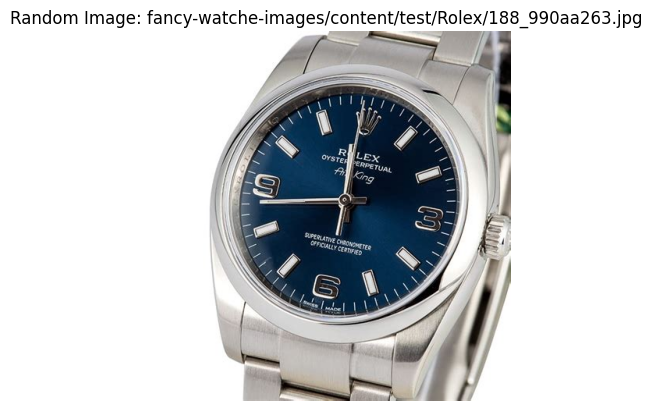

In [12]:
import random
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

random.seed(42)

# Define test_dir as a Path object
test_dir = Path('fancy-watche-images/content/test/Rolex')

# Match different image file extensions
image_path_list = list(test_dir.rglob("*.jpg"))

# Debug: Print number of images found
print(f"Number of images found: {len(image_path_list)}")

if image_path_list:
    random_image_path = random.choice(image_path_list)
    img = Image.open(random_image_path)

    # Display image using Matplotlib
    plt.imshow(img)
    plt.title(f'Random Image: {random_image_path}')
    plt.axis('off')  # Hide axis
    plt.show()
else:
    print("No images found. Please check the directory structure and file extensions.")


Number of images found: 400
Random image path: fancy-watche-images/content/test/Breitling/046_73359c27.jpg
Image class: Breitling
Image height: 474
Image width: 474


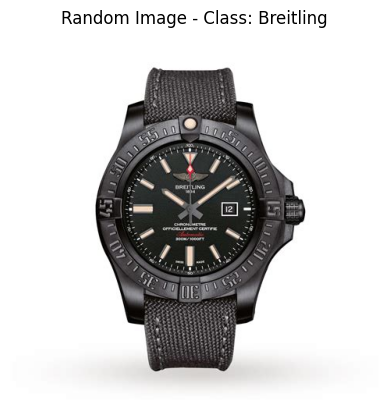

In [13]:
import random
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Set seed for reproducibility


# Define base_dir as a Path object (adjust the path to your images directory)
test_dir = Path('fancy-watche-images/content/test')

# Match different image file extensions
image_path_list = list(test_dir.rglob("*.jpg"))

# Debug: Print number of images found
print(f"Number of images found: {len(image_path_list)}")

if image_path_list:
    # Get a random image path
    random_image_path = random.choice(image_path_list)

    # Get image class from the directory name
    image_class = random_image_path.parent.stem

    # Open image
    img = Image.open(random_image_path)

    # Print metadata
    print(f"Random image path: {random_image_path}")
    print(f"Image class: {image_class}")
    print(f"Image height: {img.height}")
    print(f"Image width: {img.width}")

    # Display image using Matplotlib
    plt.imshow(img)
    plt.title(f'Random Image - Class: {image_class}')
    plt.axis('off')  # Hide axis
    plt.show()
else:
    print("No images found. Please check the directory structure and file extensions.")


In [14]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [15]:
data_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

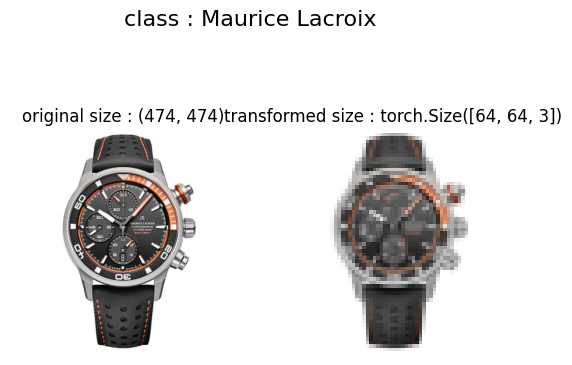

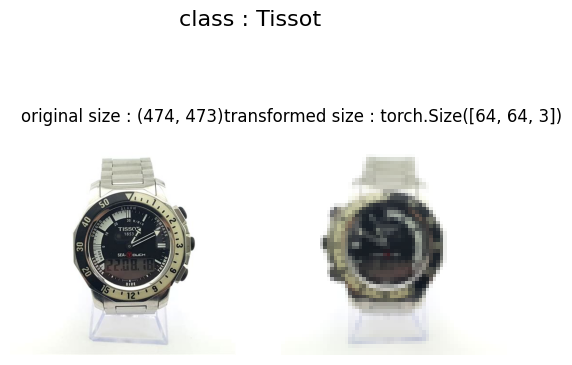

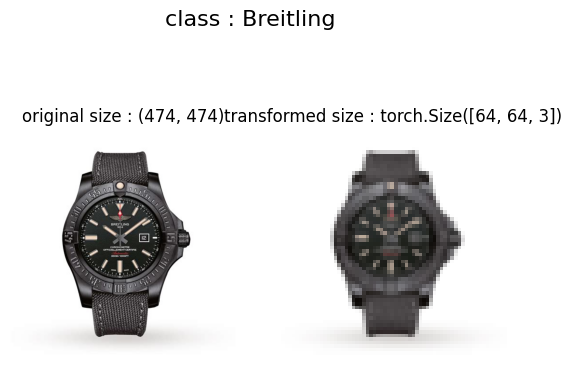

In [16]:
def plot_transform_images(image_paths,transform,n=3,seed=42):
  random.seed(seed)
  random_image_paths = random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:

      fig,ax=plt.subplots(1,2)
      ax[0].imshow(f)
      ax[0].set_title(f'original size : {f.size}')
      ax[0].axis("off")

      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f'transformed size : {transformed_image.shape}')
      ax[1].axis("off")

      fig.suptitle(f'class : {image_path.parent.stem}',fontsize=16)

plot_transform_images(image_path_list,transform=data_transform,n=3)


In [17]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,transform=data_transform,target_transform=None)
test_data = datasets.ImageFolder(root=test_dir,transform=data_transform)

print (f"train data :  \n {train_data} \n test data : \n {test_data}")

train data :  
 Dataset ImageFolder
    Number of datapoints: 1600
    Root location: fancy-watche-images/content/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           ) 
 test data : 
 Dataset ImageFolder
    Number of datapoints: 400
    Root location: fancy-watche-images/content/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )


In [18]:
class_names = train_data.classes
class_names

['Audemars Piguet',
 'Breguet',
 'Breitling',
 'Maurice Lacroix',
 'Omega',
 'Patek Philippe',
 'Rado',
 'Rolex',
 'Tissot',
 'Vacheron Constantin']

In [19]:
class_dict = train_data.class_to_idx
class_dict

{'Audemars Piguet': 0,
 'Breguet': 1,
 'Breitling': 2,
 'Maurice Lacroix': 3,
 'Omega': 4,
 'Patek Philippe': 5,
 'Rado': 6,
 'Rolex': 7,
 'Tissot': 8,
 'Vacheron Constantin': 9}

In [20]:
len(train_data),len(test_data)

(1600, 400)

In [21]:
img, label = train_data[350][0], train_data[350][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")

Image tensor:
tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])
Image shape: torch.Size([3, 64, 64])
Image datatype: torch.float32
Image label: 2
Label datatype: <class 'int'>


original shape : torch.Size([3, 64, 64]) c h w  
image permute : torch.Size([64, 64, 3]) h w c


Text(0.5, 1.0, 'Breitling')

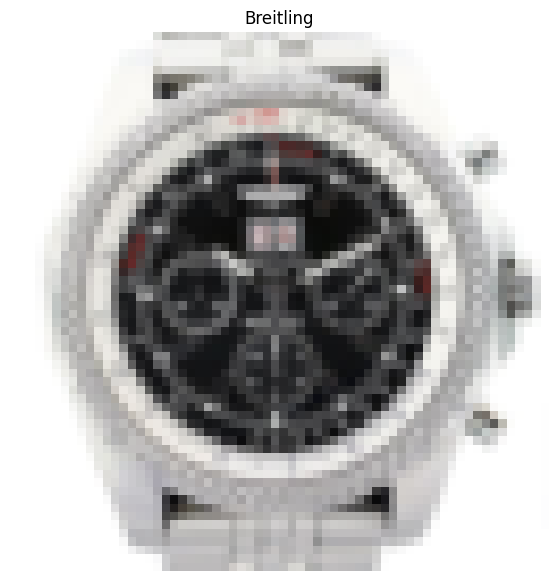

In [22]:
img_permute = img.permute(1,2,0)

print(f'original shape : {img.shape} c h w  ')
print (f'image permute : {img_permute.shape} h w c')

plt.figure(figsize=(10,7))
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.title(class_names[label])

In [23]:
os.cpu_count()

2

In [24]:
from torch.utils.data import DataLoader
train_dataloader=DataLoader(dataset=train_data,batch_size=1,num_workers=1,
                            shuffle=True)
test_dataloader = DataLoader(dataset=test_data,batch_size=1,num_workers=1,shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7dd951f835e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7dd951f80b20>)

In [25]:
img , label = next(iter(train_dataloader))
print(img.shape)
print(label.shape)

torch.Size([1, 3, 64, 64])
torch.Size([1])


In [26]:

simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

In [27]:
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,transform=simple_transform)
test_data_simple=datasets.ImageFolder(root=test_dir,transform=simple_transform)

import os
from torch.utils.data import DataLoader

BATCH_SIZE=32
NUM_WORKERS=os.cpu_count()

train_dataloader_simple = DataLoader(train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(test_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=False,
                                     num_workers=NUM_WORKERS)

train_dataloader_simple,test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x7dd9552c5450>,
 <torch.utils.data.dataloader.DataLoader at 0x7dd9552c68f0>)

In [73]:
class TinyVGG(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int) -> None:
      super().__init__()
      self.conv_block1=nn.Sequential(
          nn.Conv2d(in_channels=input_shape,
                     out_channels=hidden_units,
                     kernel_size=1,
                     stride=1,
                     padding=1),
          nn.ReLU(),
          nn.Conv2d(in_channels=hidden_units,
                     out_channels=hidden_units,
                     kernel_size=1,
                     stride=1,
                     padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )

      self.conv_block2=nn.Sequential(
          nn.Conv2d(hidden_units,hidden_units,kernel_size=1,padding=1,stride=1),
          nn.ReLU(),
          nn.Conv2d(hidden_units,hidden_units,kernel_size=1,stride=1,padding=1),
          nn.ReLU(),
          nn.MaxPool2d(2)
      )

      self.classifier=nn.Sequential(
          nn.Flatten(),
          nn.Linear(in_features=hidden_units*19*19,
                    out_features=output_shape)
      )

  def forward(self,x:torch.Tensor):
    x = self.conv_block1(x)
    #print(x.shape)
    x = self.conv_block2(x)
    #print(x.shape)
    x = self.classifier(x)
    #print(x.shape)
    return x

torch.manual_seed(42)

model0=TinyVGG(input_shape=3,hidden_units=100,
               output_shape=len(train_data.classes))
model0

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 100, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(100, 100, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(100, 100, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(100, 100, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=36100, out_features=10, bias=True)
  )
)

In [74]:

img_batch, label_batch = next(iter(train_dataloader_simple))


img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")


model0.eval()
with torch.inference_mode():
    pred = model0(img_single)

print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[ 0.0087,  0.0166, -0.0137,  0.0348, -0.0031, -0.0567, -0.0237, -0.0051,
         -0.0239,  0.0082]])

Output prediction probabilities:
tensor([[0.1014, 0.1022, 0.0992, 0.1041, 0.1002, 0.0950, 0.0982, 0.1000, 0.0982,
         0.1014]])

Output prediction label:
tensor([3])

Actual label:
3


In [30]:
!pip install torchinfo

In [31]:
import torchinfo

from torchinfo import summary

summary(model0,input_size=[1,3,64,64])

torch.Size([1, 10, 34, 34])
torch.Size([1, 10, 19, 19])


Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 34, 34]           --
│    └─Conv2d: 2-1                       [1, 10, 66, 66]           40
│    └─ReLU: 2-2                         [1, 10, 66, 66]           --
│    └─Conv2d: 2-3                       [1, 10, 68, 68]           110
│    └─ReLU: 2-4                         [1, 10, 68, 68]           --
│    └─MaxPool2d: 2-5                    [1, 10, 34, 34]           --
├─Sequential: 1-2                        [1, 10, 19, 19]           --
│    └─Conv2d: 2-6                       [1, 10, 36, 36]           110
│    └─ReLU: 2-7                         [1, 10, 36, 36]           --
│    └─Conv2d: 2-8                       [1, 10, 38, 38]           110
│    └─ReLU: 2-9                         [1, 10, 38, 38]           --
│    └─MaxPool2d: 2-10                   [1, 10, 19, 19]           --
├─Sequential

In [77]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer):
  model.train()

  train_loss,train_acc = 0,0

  for batch,(x,y) in enumerate (dataloader):

    y_pred=model(x)

    loss = loss_fn(y_pred,y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()


    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    train_loss = train_loss/len(dataloader)
    train_acc = train_acc/len(dataloader)

    return train_loss,train_acc




In [76]:
def test_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module):
  model.eval()

  test_loss,test_acc = 0,0

  with torch.inference_mode():


    for batch,(x,y) in enumerate (dataloader):

      test_pred_logits=model(x)

      loss = loss_fn(test_pred_logits,y)
      test_loss += loss.item()




    test_pred_labels = test_pred_logits.argmax(dim=1)
    test_acc += (test_pred_labels == y).sum().item()/len(test_pred_labels)

    test_loss = test_loss/len(dataloader)
    test_acc = test_acc/len(dataloader)

    return test_loss,test_acc

In [78]:
from tqdm.auto import tqdm

def training(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):


    results = {"train_loss": [],

        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }


    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)


        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )


        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)


    return results

In [79]:
torch.manual_seed(42)

NUM_EPOCHS = 5

model0=TinyVGG(input_shape=3,
               hidden_units=100,
               output_shape=len(train_data.classes))

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model0.parameters(),lr=0.001)

from timeit import default_timer as timer
start_time = timer()

model0_results = training(model=model0,
                       train_dataloader=train_dataloader_simple,
                       test_dataloader= test_dataloader_simple,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=NUM_EPOCHS
                      )

end_time = timer()

print(f"total training time : {end_time - start_time:.3f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0460 | train_acc: 0.0025 | test_loss: 2.9231 | test_acc: 0.0000
Epoch: 2 | train_loss: 0.0559 | train_acc: 0.0025 | test_loss: 2.7750 | test_acc: 0.0000
Epoch: 3 | train_loss: 0.0541 | train_acc: 0.0019 | test_loss: 2.4708 | test_acc: 0.0000
Epoch: 4 | train_loss: 0.0515 | train_acc: 0.0025 | test_loss: 2.3924 | test_acc: 0.0000
Epoch: 5 | train_loss: 0.0486 | train_acc: 0.0006 | test_loss: 2.3910 | test_acc: 0.0000
total training time : 53.273 seconds


In [80]:
model0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [82]:
def plot_loss_curves(results: dict[str, list[float]]):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """


    loss = results['train_loss']
    test_loss = results['test_loss']

    accuracy = results['train_acc']
    test_accuracy = results['test_acc']


    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))


    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

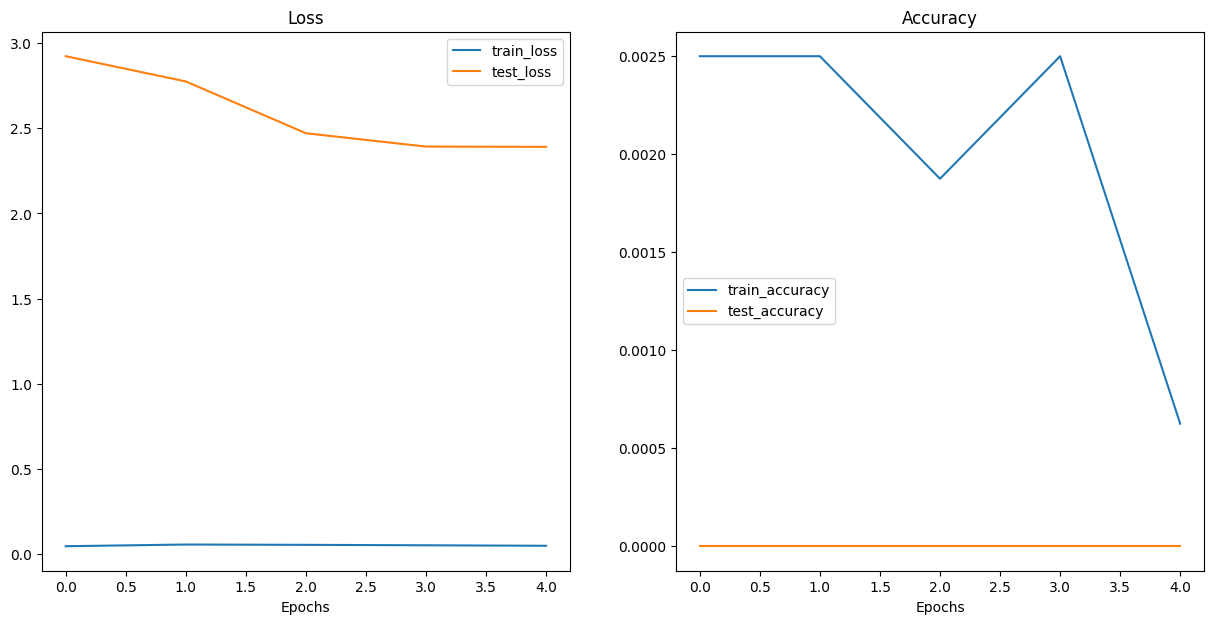

In [83]:
plot_loss_curves(model0_results)